---
authors:
  - name: Lukas Heumos
  - name: Anastasia Litinetskaya
  - name: Soroor Hediyeh-Zadeh
---


(differential-analysis)=
# Differential gene expression analysis
```{dropdown} 🧠 Key takeaways

:::{card}
:link: #conditions-differential-gene-expression-key-takeaway-1
In scRNA-seq, there are two main approaches to identify differentially expressed genes: the sample-level view and the cell-level view.
The sample-level approach has been shown to outperform the cell-level approach for scRNA-seq data.
:::

:::{card}
:link: #conditions-differential-gene-expression-key-takeaway-2
In the sample-level view, a pseudobulk sample is created for each patient and cell type by aggregating counts (e.g., summing across cells).
These pseudobulk profiles can then be analyzed using tools such as edgeR or DESeq2, which were originally developed for bulk RNA-seq data.
:::

:::{card}
:link: #conditions-differential-gene-expression-key-takeaway-3
Explore your data before modeling.
Performing PCA on pseudobulk samples can reveal major sources of variation that should be accounted for in your design matrix.
:::

:::{card}
:link: #conditions-differential-gene-expression-key-takeaway-4
Remove lowly expressed genes separately for each cell type, as different cell populations express distinct gene sets.
:::

:::{card}
:link: #conditions-differential-gene-expression-key-takeaway-5
If your dataset contains different subgroups, construct a design matrix that includes all relevant covariates.
You can then define contrasts to test the specific comparisons of interest.
:::

```
``````{dropdown} ⚙️ Environment setup
`````{tab-set}

````{tab-item} Steps
```{include} ../_static/default_text_env_setup.md
```
````

````{tab-item} yml
```{literalinclude} differential_gene_expression.yml
:language: yaml
```
````

`````
``````
````{dropdown} 🗄️ Get data and notebooks
```{include} ../_static/default_text_lamindb_setup.md
```
````
<!-- END DROPDOWNS -->


(conditions-differential-gene-expression-key-takeaway-1)=
## Motivation

This chapter is a more detailed continuation of the {term}`annotation` [subchapter](#cellular-structure-annotation-DGE) which already introduced {term}`differential gene expression (DGE)` as a tool to annotate {term}`clusters <cluster>` with {term}`cell types <cell type>`.
Here, we focus on more advanced use-cases of differential gene expression testing in complex experimental designs, which involve one or more conditions such as diseases, genetic knockouts or drugs.
In such cases we are commonly interested in the magnitude and significance of differences in gene expression patterns between the condition of interest and a reference.
This reference can be everything but is commonly a healthy sample.
This statistical test can be applied to arbitrary groups, but in the case of single-cell {term}`RNA`-Seq is commonly applied on the cell type level.

:::{figure} ../_static/images/conditions/differential_gene_expression.jpg
:name: Differential gene expression overview
:alt: DGE analysis overview
:class: bg-primary mb-1
:width: 800px

DGE analysis attempts to infer genes that are statistically significantly over- or underexpressed between any compared groups (commonly between healthy and condition per cell type).
:::

The outcome of such an analysis could be genesets which effect and potentially explain any observed phenotypes.
These genesets can then be examined more closely with respect to, for example, affected pathways or induced cell-cell communication changes.

A differential gene expression test usually returns the log2 fold-change and the adjusted p-value per compared genes per compared conditions. This list can then be sorted by p-value and investigated in more detail.

The popular student's t-test is one way of conducting such a test.
However, it fails to take several single-cell RNA-seq peculiarities into account such as the excess number of zeros originating from {term}`dropouts <Dropout>` or the need for complex experimental designs.
More specifically, very rarely does one have sufficient sample numbers to accurately estimate the variance without pooling information across genes.
Moreover, raw counts are never an absolute measurement of expression for a specific gene within a given sample.
The actual read number per gene depends on the efficiency of the {term}`library` preparation, the amount of contamination from non-coding transcripts and the {term}`sequencing` depth.
It does therefore lack in both, sensitivity and specificity for single-cell RNA-seq, let alone experimental design flexibility.

As a result, DGE testing is a classic bioinformatics problem which has been tackled by many tools already.
Generally, the problem is currently being approached from two views, the sample-level view where expression is aggregated to create “{term}`pseudobulks <Pseudobulk>`" and then analysed with methods originally designed for {term}`bulk expression <Bulk RNA sequencing>` samples such as edgeR {cite:p}`de:Robinson2010` or DEseq2 {cite:p}`de:Love2014` and the cell-level view where {term}`cells <cell>` are modeled individually using generalized mixed effect models such as MAST {cite:p}`de:Finak2015` or glmmTMB {cite:p}`de:Brooks2017`. 
The consensus and robustness across datasets for DGE tools is low {cite:p}`de:Wang2019,de:Das2021`. As previously described, although single-cell data contains technical noise artifacts such as dropout, zero-inflation and high cell-to-cell variability {cite:p}`de:Hicks2017,de:Vallejos2017,de:Lücken2019`, methods designed for bulk RNA-seq data performed favorably compared to methods explicitly designed for scRNA-seq data {cite:p}`de:Das2021,de:Soneson2018,de:Jaakkola2016,de:Squair2021`.
Single-cell specific methods were found to be especially prone to wrongly labeling highly expressed genes as differentially expressed.

A recent study highlighted the issue of pseudoreplication where inferential statistics is applied to biological replicates which are not statistically independent.
Failing to account for the inherent correlation of replicates (cells from the same individual) inflates the false discovery rate (FDR) {cite:p}`de:Squair2021,de:Zimmerman2021,de:Junttila2022`.
Therefore, {term}`batch effect` correction or the aggregation of cell-type-specific expression values within an individual through either a sum, mean or random effect per individual, that is pseudobulk generation, should be applied prior to DGE analysis to account for within-sample correlations {cite:p}`de:Zimmerman2021`.
Generally, both, pseudobulk methods with sum aggregation such as edgeR, DESeq2, or Limma {cite:p}`de:Ritchie2015` and mixed models such as MAST with random effect setting were found to be superior compared to naive methods, such as the popular Wilcoxon rank-sum test or Seurat’s {cite:p}`de:Hao2021` latent models, which do not account for them {cite:p}`de:Junttila2022`.

In matters arising from the Zimmerman paper, Murphy et al. critically examined the Zimmerman {term}`benchmarking <Benchmark>` strategy and improved it {cite:p}`de:Murphy_2022`.
They came to the conclusion that pseudobulk methods perform best but whether sum or mean aggregation works better requires further investigation.

Hence, in this notebook, we demonstrate how to perform DGE analysis using the pseudobulk approach.
We choose DESeq2 due to its Python implementation, PyDESeq2.
However, the code can be easily adapted for use with edgeR by following the [pertpy tutorial on differential gene expression](https://pertpy.readthedocs.io/en/stable/tutorials/notebooks/differential_gene_expression.html#differential-expression-testing-with-edger).
For this chapter, we combined parts of the tutorials from [decoupler](https://decoupler.readthedocs.io/en/latest/notebooks/scell/rna_psbk.html) and [pertpy](https://pertpy.readthedocs.io/en/stable/tutorials/notebooks/differential_gene_expression.html).
Please refer to their documentation for more details.

## Environment setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import decoupler as dc
import lamindb as ln
import numpy as np
import pandas as pd
import pertpy as pt
import scanpy as sc

ln.connect("theislab/sc-best-practices")

ln.track("zt7x1ebMcoIA")

→ connected lamindb: theislab/sc-best-practices


→ found notebook differential_gene_expression.ipynb, making new version -- luisheinzlmeier already works on this draft


→ created Transform('zt7x1ebMcoIA0001', key='differential_gene_expression.ipynb'), started new Run('vEbb3sduUoKQ5nDY') at 2026-09-29 19:17:12 UTC


→ notebook imports: decoupler==2.2.0 lamindb-core==2.8.1 numpy==2.5.3 pandas==2.3.3 pertpy==1.2.0 scanpy==1.12.3


## Preparing the dataset

We will use the Kang dataset, which is a 10x droplet-based scRNA-seq peripheral blood mononuclear cell (PBMC) data from 8 Lupus patients before and after 6h-treatment with INF-β (16 samples in total) {cite:p}`de:kang2018`.
Interferon beta is used in the form of natural fibroblast or recombinant preparations (interferon beta-1a and interferon beta-1b) and exerts antiviral and antiproliferative properties similar to those of interferon alpha.
Interferon beta has been approved for the treatment of relapsing–remitting multiple sclerosis and secondary progressive multiple sclerosis. 

First, we load the full dataset.

In [3]:
adata = ln.Artifact.get(
    key="conditions/differential_gene_expression.h5ad",
).load()
adata

AnnData object with n_obs × n_vars = 24673 × 15706
    obs: 'nCount_RNA', 'nFeature_RNA', 'tsne1', 'tsne2', 'label', 'cluster', 'cell_type', 'replicate', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.4', 'seurat_clusters'
    var: 'name'
    obsm: 'X_pca', 'X_umap'

We will need `label` (which contains the condition label), `replicate` (patient id) and `cell_type` columns of the `.obs`.

In [4]:
adata.obs[:5]

,nCount_RNA,nFeature_RNA,tsne1,tsne2,label,cluster,cell_type,replicate,nCount_SCT,nFeature_SCT,integrated_snn_res.0.4,seurat_clusters
index,,,,,,,,,,,,
AAACATACATTTCC-1,3017.0,877,-27.640373,14.966629,ctrl,9,CD14+ Monocytes,patient_1016,1704.0,711,1,1
AAACATACCAGAAA-1,2481.0,713,-27.493646,28.924885,ctrl,9,CD14+ Monocytes,patient_1256,1614.0,662,1,1
AAACATACCATGCA-1,703.0,337,-10.468194,-5.984389,ctrl,3,CD4 T cells,patient_1488,908.0,337,6,6
AAACATACCTCGCT-1,3420.0,850,-24.367997,20.429285,ctrl,9,CD14+ Monocytes,patient_1256,1738.0,653,1,1
AAACATACCTGGTA-1,3158.0,1111,27.952170,24.159738,ctrl,4,Dendritic cells,patient_1039,1857.0,928,12,12


We will need to work with raw counts so we check that `.X` indeed contains raw counts and put them into the `counts` layer of our {term}`AnnData` object.

In [5]:
X = adata.X.data
np.array_equal(X, np.round(X))

True

In [6]:
adata.layers["counts"] = adata.X.copy()

We have 8 control and 8 disease patients.

In [7]:
print(len(adata[adata.obs["label"] == "ctrl"].obs["replicate"].cat.categories))
print(len(adata[adata.obs["label"] == "stim"].obs["replicate"].cat.categories))

8
8


We filter cells which have less than 200 genes and genes which were found in less than 3 cells for a rudimentary quality control.

In [8]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata.shape

(24562, 15701)

(conditions-differential-gene-expression-key-takeaway-2)=
## Pseudobulking

Since PyDESeq2 was introduced as a method for DGE analysis for bulk data, we first need to create pseudobulk samples from our single-cell dataset.
For each patient we create one pseudobulk sample per cell type by aggregating the cells from each subpopulation and taking the sum of gene expression counts.
Regardless of whether we want to run the analysis only on a few cell subpopulations and fit a model for each one of them separately or fit one model for all of them, we first need to prepare the data.

Since we need to create pseudobulks for each patient-condition combination, we first need to create such a column by concatenating `replicate` and `label`.

In [9]:
adata.obs["sample"] = pd.Categorical(
    f"{rep}_{l}" for rep, l in zip(
        adata.obs["replicate"],
        adata.obs["label"],
        strict=False
    )
)

Next, we generate pseudobulk samples using decoupler. With 8 patients, 8 cell types, and 2 conditions (`ctrl` and `stim`), this yields a total of 128 pseudobulks (8 x 8 x 2).

In [10]:
adata_pb = dc.pp.pseudobulk(
    adata, sample_col="sample",
    groups_col="cell_type",
    layer="counts",
    mode="sum"
)
adata_pb

AnnData object with n_obs × n_vars = 128 × 15701
    obs: 'sample', 'cell_type', 'label', 'replicate', 'psbulk_cells', 'psbulk_counts'
    var: 'name', 'n_cells'
    layers: 'psbulk_props'

Low-quality samples can be filtered using two criteria: the number of cells (`psbulk_cells`) and the total count sum (`psbulk_counts`). 
These metrics can be visualized in the following plot to guide filtering decisions.

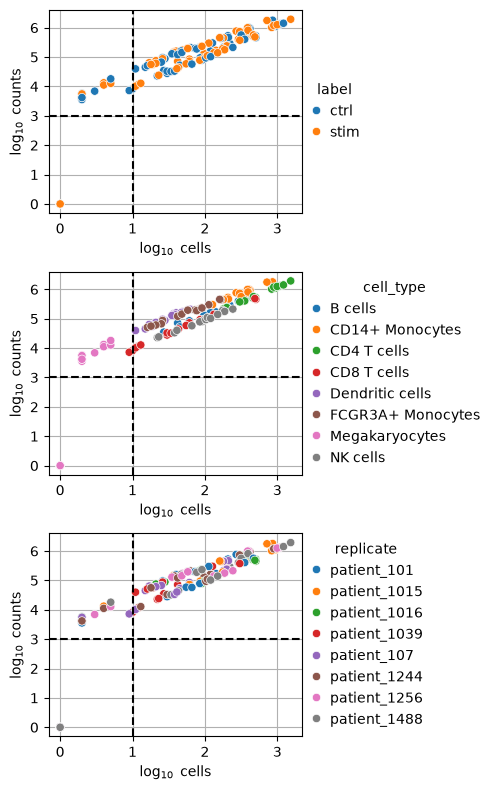

In [11]:
dc.pl.filter_samples(
    adata=adata_pb,
    groupby=["label", "cell_type", "replicate"],
    min_cells=10,
    min_counts=1000,
    figsize=(5, 8),
)

While thresholds are dataset-specific and arbitrary, a commonly used guideline is to retain samples with a minimum of 10 cells and 1,000 total counts. 
Applying these thresholds (indicated by dashed lines) restricts the dataset to pseudobulks in the upper-right quadrant. 
The filtering step can be carried out with `decoupler.pp.filter_samples()`.

In [12]:
dc.pp.filter_samples(adata_pb, min_cells=10,min_counts=1000)

After filtering out low-quality samples, we can visualize the remaining profiles. 
All megakaryocyte pseudobulk samples failed quality control, and two CD8 T cell samples were removed.

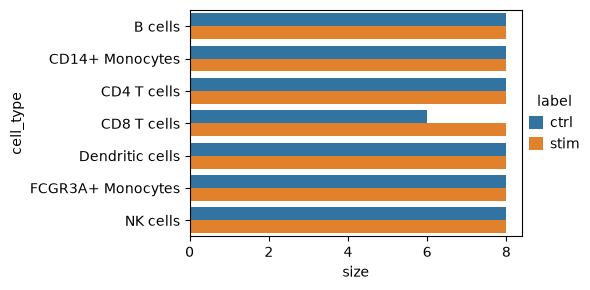

In [13]:
dc.pl.obsbar(adata=adata_pb, y="cell_type", hue="label", figsize=(6, 3))

(conditions-differential-gene-expression-key-takeaway-3)=
## Variability Exploration

The validity of DGE results highly depends on the capture of the major axis of variations in the statistical model.
Intermediate data exploration steps such as {term}`principal component analysis (PCA)` or multidimensional scaling (MDS) on pseudobulk samples allow for the identification of the sources of variation and thus can guide the construction of corresponding design and contrast matrices that model the data {cite:p}`de:Law2020`. 

Failing to account for multiple sources of biological variability for experiments which include biological replicates will inflate the FDR {cite:p}`de:Thurman2021,de:Lähnemann2020`.
While increasing the number of cells per individual increases the precision, it has a limited effect on the power for the detection of differences across individuals.
Therefore, the best way to increase statistical power is to increase the number of independent experimental samples {cite:p}`de:Zimmerman2021`.

Since our data has already been generated, we cannot further increase the number of independent experimental samples.
Nevertheless, we will now explore our data to determine the major axes of variation to properly generate our design matrices.

We perform very basic exploratory data analysis on the generated pseudo-replicates to identify potential outliers among patients or pseudobulks.
These outliers can then be excluded to avoid biasing the differential expression results.
We store the raw counts in the `'counts'` layer, then normalize and scale them before computing PCA. 
Afterwards, we revert to the raw counts for {term}`downstream analysis`.

In [14]:
adata_pb.layers['counts'] = adata_pb.X.copy()

sc.pp.normalize_total(adata_pb, target_sum=1e6)
sc.pp.log1p(adata_pb)
sc.pp.scale(adata_pb, max_value=10)
sc.tl.pca(adata_pb)

dc.pp.swap_layer(adata=adata_pb, key="counts", inplace=True)

We also include `psbulk_counts_log` and `psbulk_cells_log` because taking the log makes library sizes (`psbulk_counts` and `psbulk_cells`) less skewed and allows more reliable detection of correlations with principal components.

In [15]:
adata_pb.obs["psbulk_counts_log"] = np.log(adata_pb.obs["psbulk_counts"])
adata_pb.obs["psbulk_cells_log"] = np.log(adata_pb.obs["psbulk_cells"])

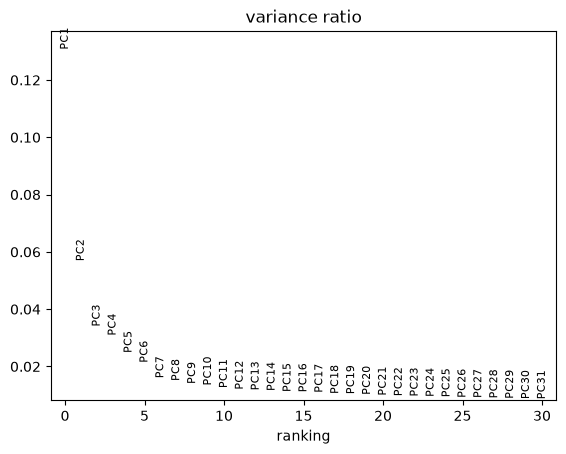

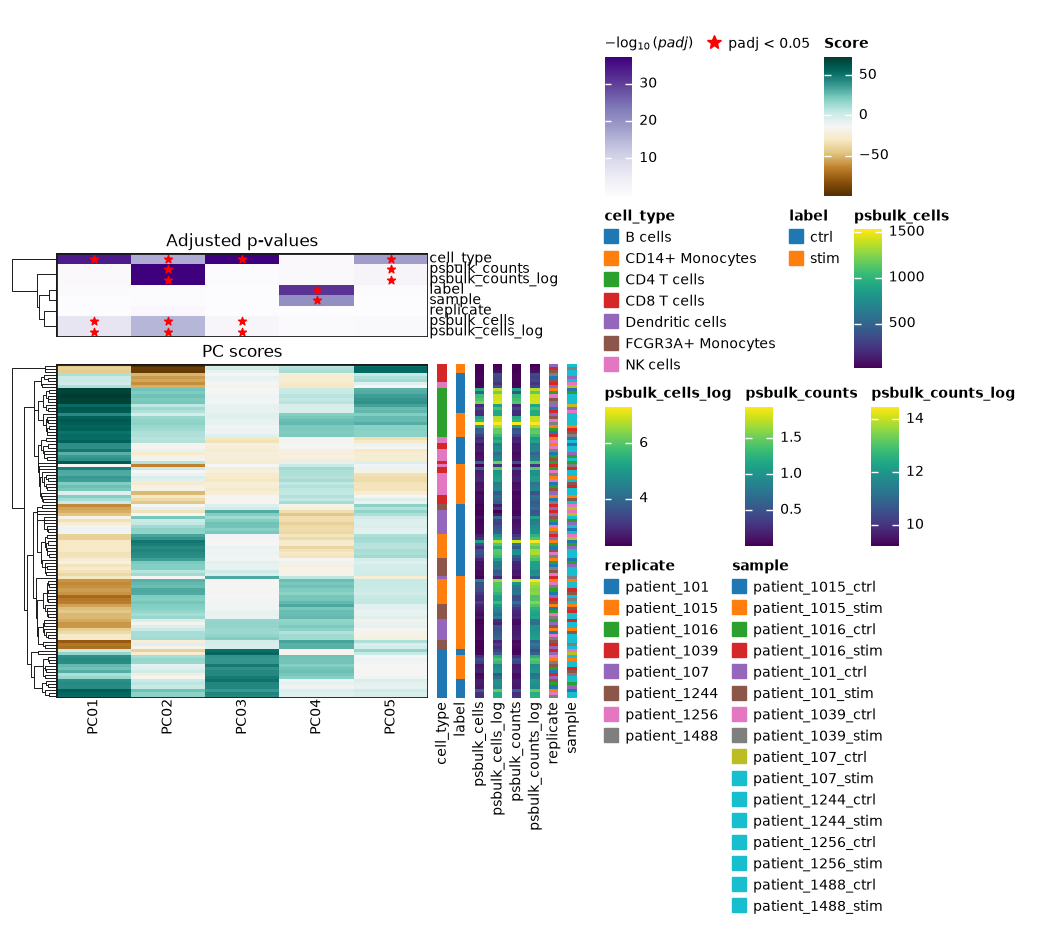

In [16]:
dc.tl.rankby_obsm(adata_pb, key="X_pca")
sc.pl.pca_variance_ratio(adata_pb)
dc.pl.obsm(
    adata=adata_pb,
    return_fig=True,
    nvar=5,
    titles=["PC scores", "Adjusted p-values"],
    figsize=(10, 5)
)

In this dataset, PC1 appears to explain the largest proportion of variance because it shows the highest variance ratio of around 0.13.
It is associated with the metadata variables cell type and pseudobulk cells.
Metadata variables associated with PCs that capture a substantial amount of variance are important and should be accounted for as relevant covariates (e.g., include in the design matrix) in downstream differential expression analysis when possible.
The principal components can also be directly visualized, colored by these metadata variables.

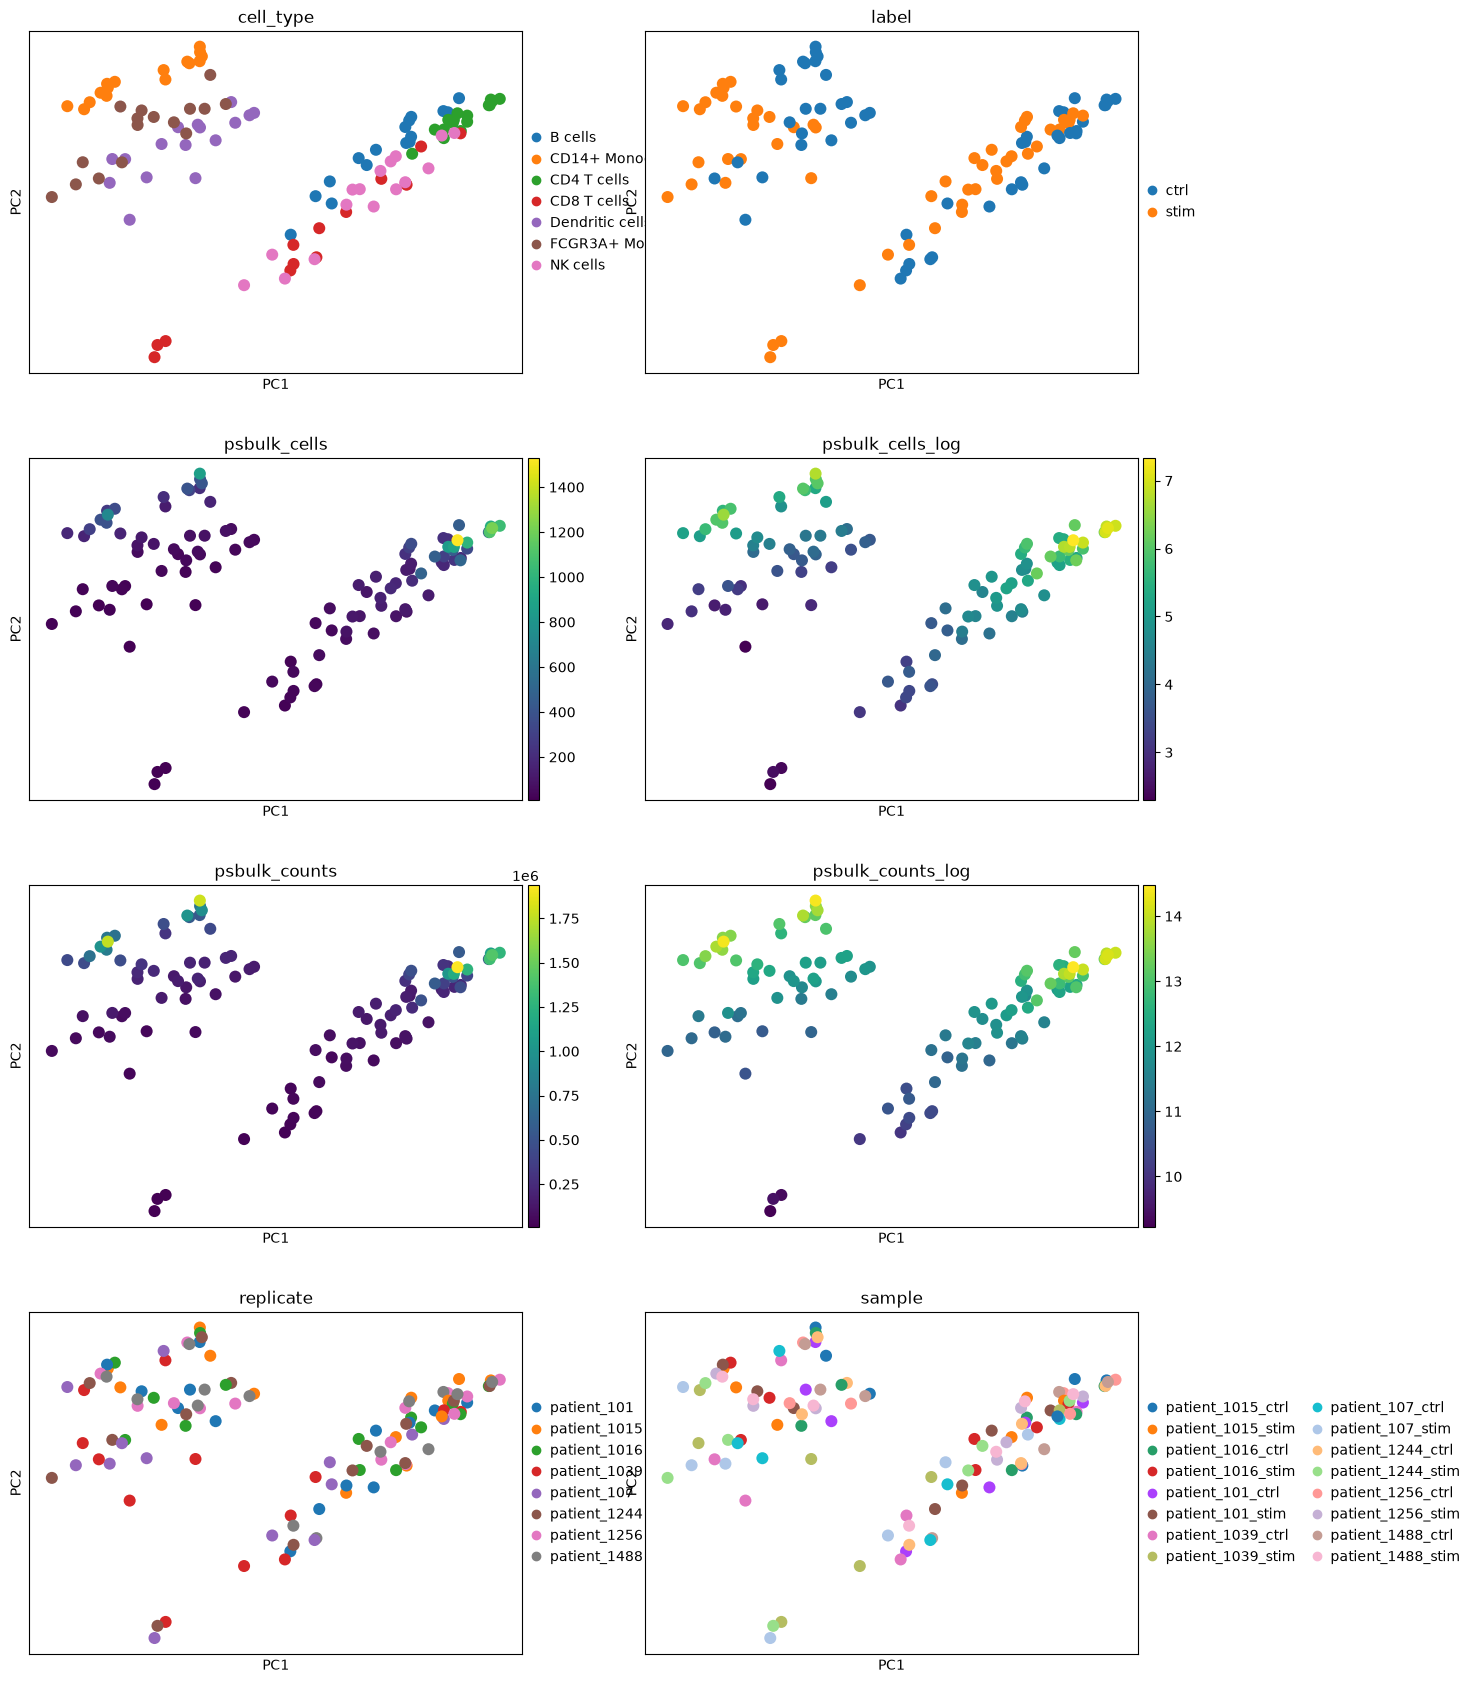

In [17]:
adata_pb.obs = adata_pb.obs.sort_index(axis=1)
sc.pl.pca(adata_pb, color=adata_pb.obs, ncols=2, size=300)

We observe separation of cell types on the PCA plots as well as the separation into stimulated and unstimulated cells.
For pseudobulk cells and counts, we can also observe some clustering, with high values appearing in the top left and top right regions.
Looking more closely, we see that these clusters of high values partially overlap with specific cell type clusters: the top right cluster overlaps with CD4 T cells, while the top left cluster overlaps with CD14+ monocytes.
This suggests that the number of cells and counts assigned to a pseudospot may depend on the pseudospot's cell type.
The covariates replicate and sample do not seem to be clearly correlated with the PCA components so we do not include any of them in our design matrix.

(one-cell-type-or-group)=
## One cell type or group
If you already know which cell types to focus on, subset them at this step to reduce confounding factors.
Otherwise, you can first [analyze the full dataset](#conditions-differential-gene-expression-key-takeaway-5) to identify the most affected cell types, then return to this step.

If variability exploration showed that cell types are associated with PCs, it may help to rerun it on your cell type subsets to see if covariate effects disappear.
In our case, the association with pseudobulk cells disappears in CD14+ monocytes.
That's why we won't include it into our first design matrix.


(conditions-differential-gene-expression-key-takeaway-4)=
### Feature selection

In addition to filtering low-quality samples, lowly or noisily expressed genes can also be filtered prior to DGE analysis.
This step should be performed at the cell type level, as different cell types may express distinct sets of genes.
We run the {term}`pipeline` on CD14+ monocytes subset of the data, as it was shown in the paper that the highest number of differentially expressed genes was identified in this subpopulation.

In [18]:
adata_mono = adata_pb[adata_pb.obs["cell_type"] == "CD14+ Monocytes"].copy()
adata_mono.shape

(16, 15701)

Two strategies are used to filter genes:

1. `decoupler.pp.filter_by_expr`: Retains genes with a minimum total number of reads across all samples (`min_total_count`) and a minimum number of counts in a given number of samples (`min_count`). 
This approach was introduced in [edgeR](https://rdrr.io/bioc/edgeR/man/filterByExpr.html) {cite:p}`de:Robinson2010`.
2. `decoupler.pp.filter_by_prop`: Retains genes that are expressed in at least a specified proportion of cells (`min_prop`) across a minimum number of samples (`min_smpls`).
The number of retained genes can be visualized, and the filtering parameters can be adjusted interactively.

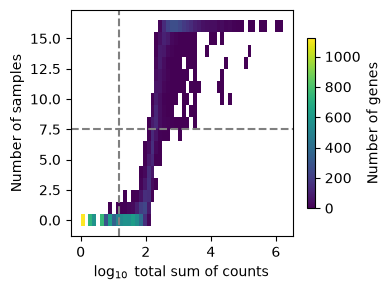

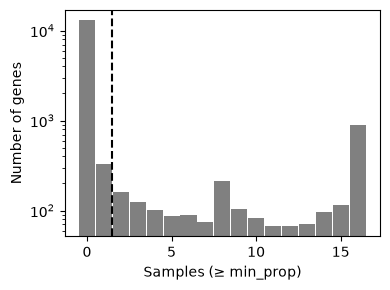

In [19]:
dc.pl.filter_by_expr(
    adata=adata_mono,
    group="label",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pl.filter_by_prop(
    adata=adata_mono,
    min_prop=0.1,
    min_smpls=2,
)

The top plot displays gene frequencies based on the `filter_by_expr` metrics, while the bottom plot corresponds to `filter_by_prop`.
Dashed lines indicate the current threshold values.
In the top plot, only genes in the upper-right quadrant are retained, in the bottom plot, only those to the right of the vertical line are kept.

Although filtering thresholds are arbitrary, a common heuristic is to look for bimodal distributions and set thresholds that separate low-quality genes from the rest.
In this example, the default parameters retain a substantial number of genes while removing potentially noisy ones.

Once the threshold parameters are set, the actual gene filtering can be performed by simply changing `pl` to `pp`.

In [20]:
dc.pp.filter_by_expr(
    adata=adata_mono,
    group="label",
    min_count=10,
    min_total_count=15,
    large_n=10,
    min_prop=0.7,
)
dc.pp.filter_by_prop(
    adata=adata_mono,
    min_prop=0.1,
    min_smpls=2,
)
adata_mono.shape

(16, 2345)

### Differential expression testing with PyDESeq2
We now switch to the pertpy package, as it makes it easier to use its built-in plotting functions.
However, DGE analysis can also be performed manually using PyDESeq2.
The interface of PyDESeq2 in pertpy is very similar.

At the next step, it is important to define an appropriate design matrix for the model.
For this purpose, we strongly recommend reading [this guide](https://f1000research.com/articles/9-1444), which provides a helpful introduction to design matrices.

```{admonition} Understand the design syntax
:class: tip, dropdown
:name: design-syntax
We combine all the variables we would like to include in our model with a `+`. 
The variable names correspond to the column names ins `.obs`.
Interactions between variables can be added to the model with `:`.
For example, the model `y ~ a + b + a:b` includes the effect of `a` and `b` on `y` as well as how the effect of `a` on `y` changes depending on `b` and vice versa.
In our context, `y` is the observed gene expression and `a` and `b` could be `label` and `cell_type`.
Now it also becomes clear where the `~` comes from: It separates the two sides of a formula.
So just add `~` at the beginning of your design.
Besides that, it might be useful to know that `a * b` is shorthand for `a + b + a:b`.
In most cases, this is all you need.
For a deeper dive, we recommend reading the [formulaic](https://matthew.wardrop.casa/formulaic/latest/formulas/) and [patsy](https://patsy.readthedocs.io/en/latest/formulas.html) documentation.
```

In [21]:
pds2 = pt.tl.PyDESeq2(adata=adata_mono,design='~ label')

In [22]:
pds2.fit()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.



Fitting dispersions...


... done in 0.26 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...


... done in 0.31 seconds.

Fitting LFCs...


... done in 0.26 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 2 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.



Before testing, we check the dispersion estimates of the fitted model.

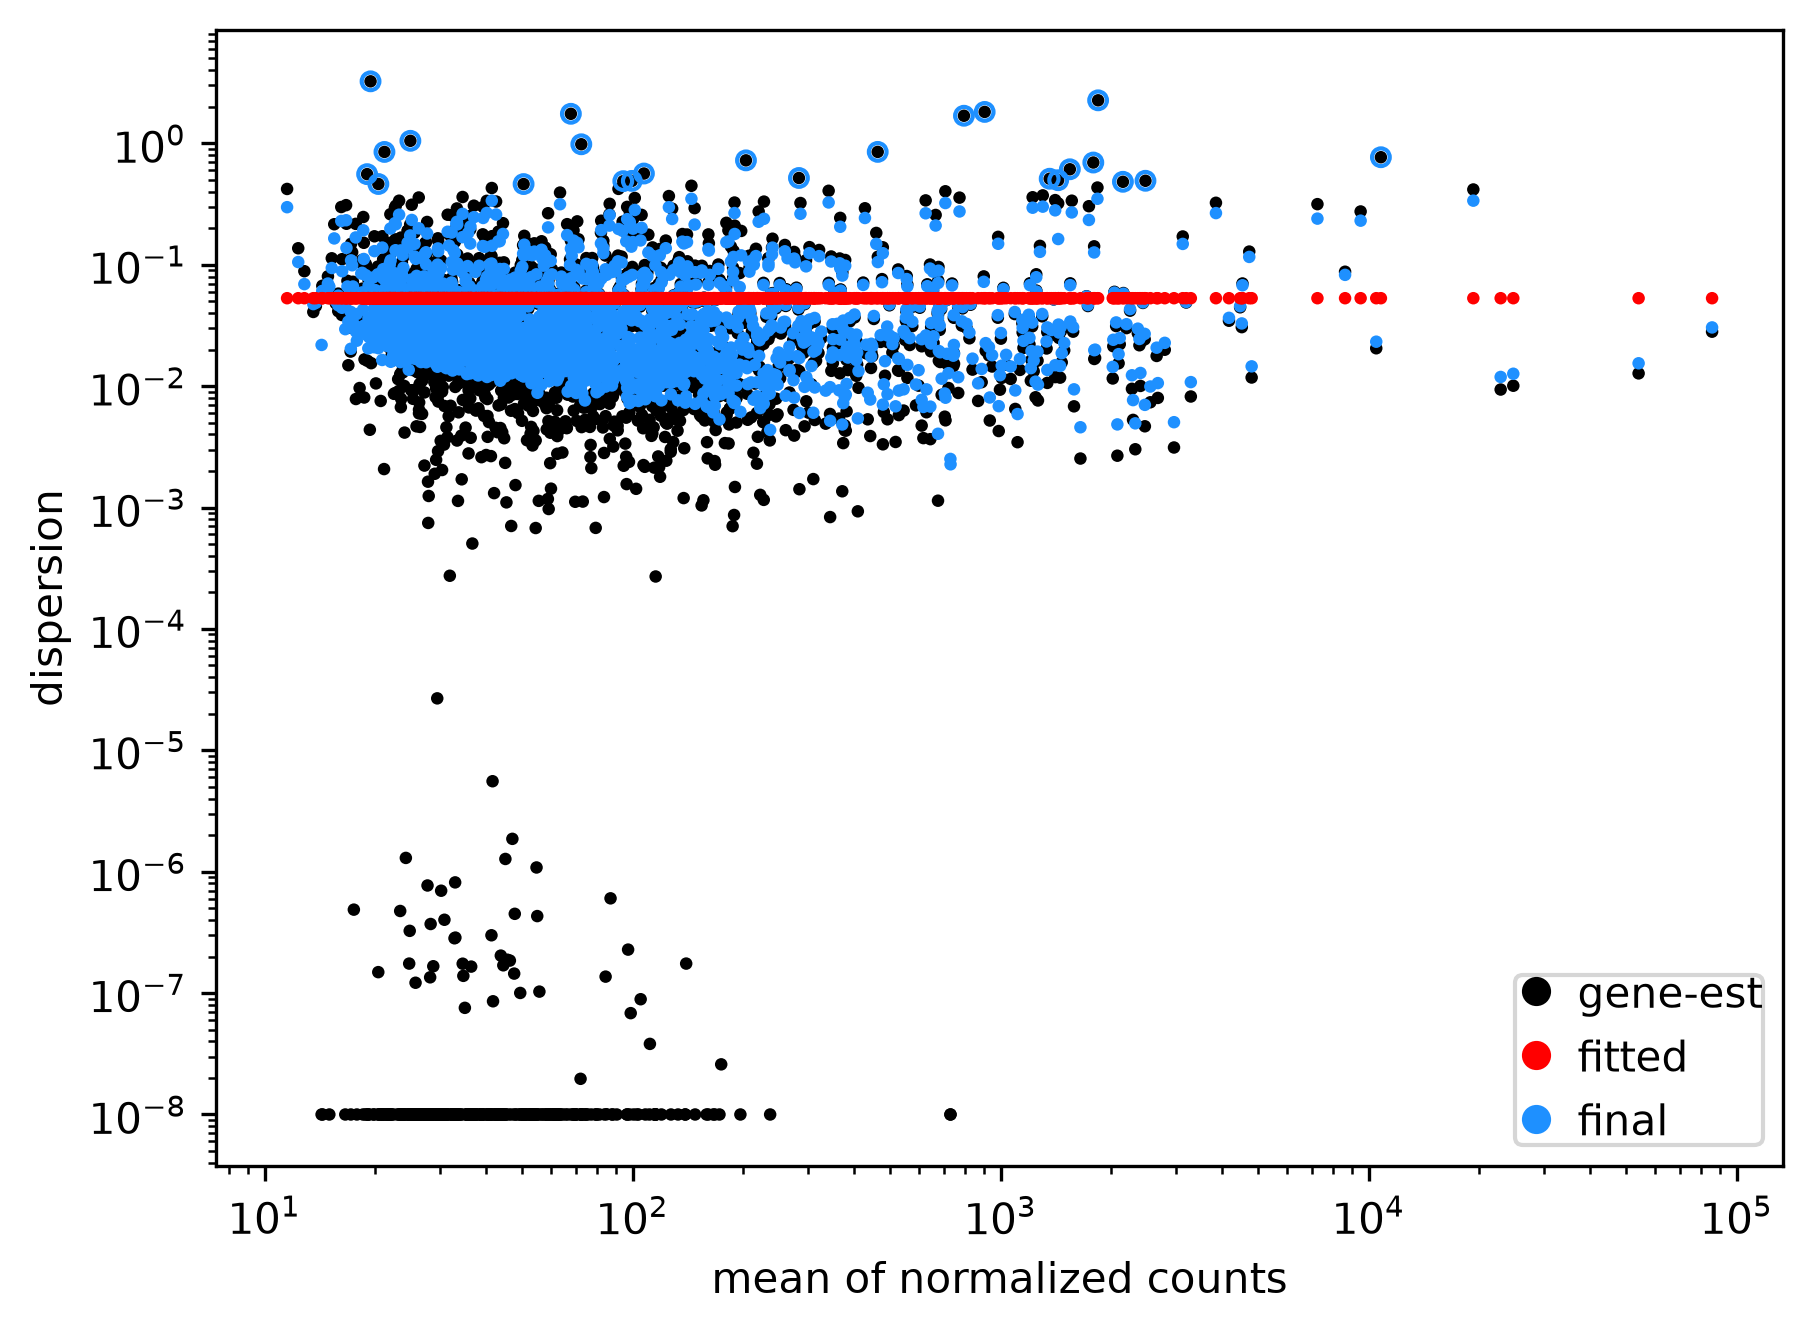

In [23]:
pds2.plot_disp_ests()

The gene-wise estimates (black) are shrunk towards the fitted trend (red) to obtain the final estimates (blue) used for testing.
Here, the trend is flat because PyDESeq2 could not fit a parametric mean-dispersion relationship and fell back to the mean dispersion.

In [24]:
res_df = pds2.test_contrasts(pds2.contrast(
    column="label",
    baseline="ctrl",
    group_to_compare="stim")
)

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
              baseMean  log2FoldChange     lfcSE       stat        pvalue  \
index                                                                       
HES4        179.827743        6.600818  0.378994  17.416675  6.165787e-68   
ISG15     19252.031373        7.076825  0.420063  16.847048  1.102835e-63   
SDF4         28.927758       -0.757190  0.178373  -4.244993  2.186003e-05   
UBE2J2       25.529327       -0.889015  0.187872  -4.732029  2.222861e-06   
AURKAIP1    115.547324       -0.572923  0.097558  -5.872663  4.288503e-09   
...                ...             ...       ...        ...           ...   
CSTB       1201.426144        0.864196  0.189353   4.563945  5.020113e-06   
SUMO3        72.227191       -0.429376  0.109301  -3.928390  8.551647e-05   
PTTG1IP      54.543949        0.213317  0.135536   1.573880  1.155153e-01   
ITGB2        41.979324        1.341234  0.240238   5.582937  2.364909e-08   
PRMT2        

... done in 0.22 seconds.



In [25]:
res_df.head(10)

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,IFITM2,491.867844,4.670294,0.151399,30.847651,6.023029e-209,1.412400e-205,None
1,IL1RN,900.090770,6.466404,0.223543,28.926924,5.476266e-184,6.420921e-181,None
2,NT5C3A,221.226625,5.583271,0.193518,28.851379,4.868960e-183,3.805904e-180,None
3,SSB,365.880933,3.336527,0.116115,28.734758,1.404456e-181,8.233624e-179,None
4,RABGAP1L,211.055152,5.994198,0.230389,26.017748,3.119036e-149,1.462828e-146,None
5,RTCB,152.556535,3.431247,0.134169,25.574152,2.958666e-144,1.156345e-141,None
6,DYNLT1,948.183449,2.609925,0.102506,25.461198,5.306293e-143,1.777608e-140,None
7,CCL8,7259.221485,9.389465,0.369928,25.381894,3.996615e-142,1.171508e-139,None
8,CXCL11,1433.690007,9.021031,0.357818,25.211192,3.019688e-140,7.867966e-138,None
9,DDX58,201.134679,4.946997,0.200032,24.731081,4.954610e-135,1.161856e-132,None


Let’s take a look at the columns in the [results table](https://hbctraining.github.io/DGE_workshop_salmon/lessons/05_DGE_DESeq2_analysis2.html#:~:text=Results%20exploration):
- `variable`. gene name
- `baseMean`: mean of normalized counts for all samples
- `log_fc`: log2 fold change
- `lfcSE`: standard error
- `stat`: Wald statistic
- `p_value`: Wald test p-value
- `adj_p_value`: Benjamini-Hochberg adjusted p-values

The rows are sorted by `adj_p_value`.
The `log_fc` always depends on the defined baseline. A positive `log_fc` means gene expression is higher in the group of interest compared to the baseline group, while negative values indicate lower expression.
In this case, _IFITM2_ increased by around 4.7 in stimulated compared to control CD14+ monocytes.
In contrast, _VCAN_ decreased by around 4.4 (see the plot below).

Next, we visualize the results.

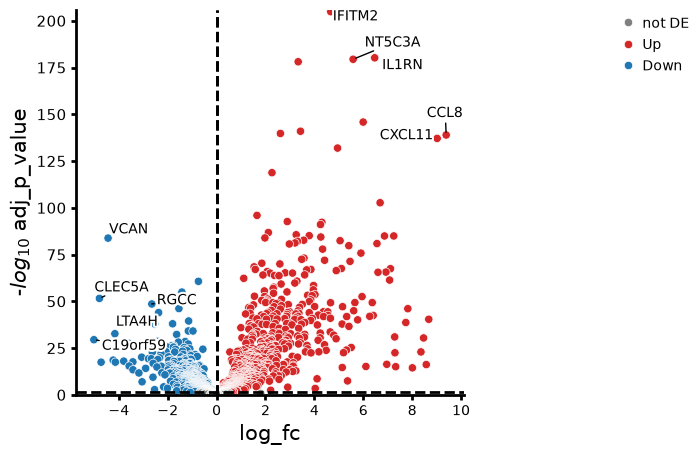

In [26]:
pds2.plot_volcano(res_df, log2fc_threshold=0)

The higher a point is on the y-axis, the smaller the `adj_p_value`.
The further a point is from 0 on the x-axis, the larger the change in expression.
Overall, this means that genes in the upper left and upper right regions of the plot show the strongest changes in gene expression and, at the same time, are also the least likely to have changes that occurred by chance.

The MA plot shows the log2 fold change of every gene against its mean expression, with significant genes highlighted.
It reveals whether the detected changes are biased towards lowly or highly expressed genes.

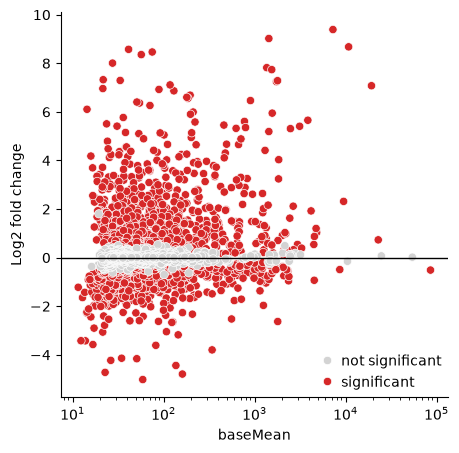

In [27]:
pds2.plot_ma(res_df)

We can also visualize our results for different subgroups.
In this case, we plot the results for individual patients.

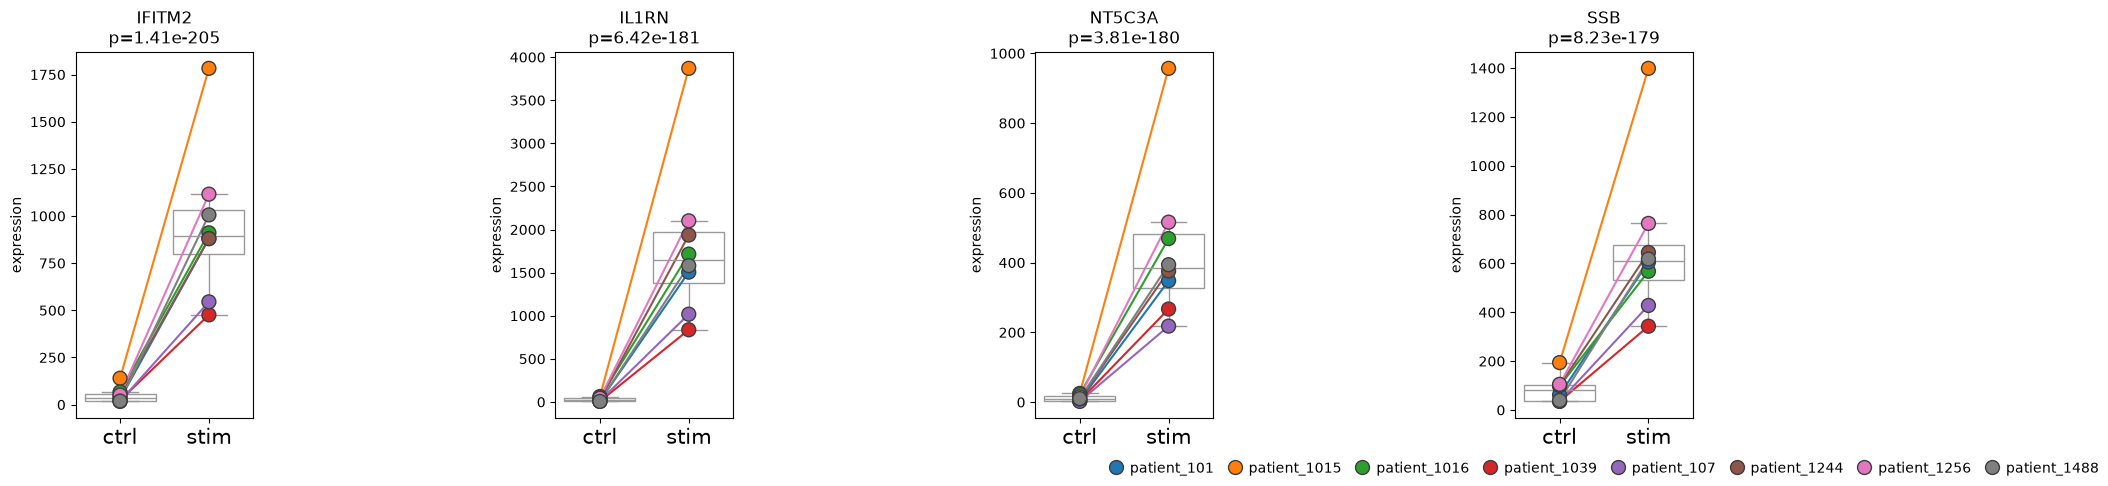

In [28]:
pds2.plot_paired(
    adata_mono,
    results_df=res_df,
    n_top_vars=4,
    groupby="label",
    pairedby="replicate"
)

We can see that the CD14+ monocytes from patient 1015 appear to be highly responsive to the treatment.

In [29]:
af = ln.Artifact.from_dataframe(res_df, key="conditions/differential_gene_expression/res_df_CD14_Monocytes.parquet").save()

→ creating new artifact version for key 'conditions/differential_gene_expression/res_df_CD14_Monocytes.parquet' in storage 's3://lamin-eu-central-1/VPwcjx3CDAa2'


... uploading Mem61XmLNGot02R90001.parquet:  0.0%

... uploading Mem61XmLNGot02R90001.parquet: 100.0%


:::{attention} Downstream analysis
We save the differential gene expression results for downstream {term}`gene set enrichment analysis <Gene set enrichment analysis (GSEA)>`.
See the [corresponding chapter](./gsea_pathway.ipynb#population-contrast-enrichment-scoring) for details.
:::

(conditions-differential-gene-expression-key-takeaway-5)=
## Multiple cell types or groups

If you’re unsure which cell type will be most affected by a treatment, a good starting point is to fit a model to the entire dataset.
Afterwards, you can return to the analysis steps from the [first part of this chapter](#one-cell-type-or-group) and focus on the cell type of interest.

In addition, the following steps demonstrate how to handle analyses involving multiple groups within the data.
You may already know which cell type you want to examine more closely, but your dataset might include multiple groups (e.g., sex, responder vs. non-responder status or age groups).
Then, this section provides an initial glimpse of the types of questions you can explore for a single cell type across multiple groups.

Since we do not have particularly interesting subgroups within our CD14+ monocyte subset (`adata_mono`), we will instead analyze multiple cell types together.
Because this analysis includes several cell types simultaneously, we will skip the feature selection step at this stage.
Feature selection is better performed at the level of individual cell types, as different cell types can express distinct gene sets.

We will begin by constructing a simple [design matrix](#design-syntax).

In [30]:
pds2 = pt.tl.PyDESeq2(adata=adata_pb, design="~ label")

In [31]:
pds2.fit()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.



Fitting dispersions...


... done in 0.71 seconds.

Fitting dispersion trend curve...
... done in 0.18 seconds.

Fitting MAP dispersions...


... done in 1.13 seconds.

Fitting LFCs...


... done in 0.87 seconds.

Calculating cook's distance...
... done in 0.07 seconds.

Replacing 36 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.



In [32]:
res_df = pds2.compare_groups(
    adata_pb,
    column="label",
    baseline="ctrl",
    groups_to_compare=["stim"]
)

Fitting size factors...


... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...


... done in 0.71 seconds.

Fitting dispersion trend curve...
... done in 0.13 seconds.

Fitting MAP dispersions...


... done in 0.58 seconds.

Fitting LFCs...


... done in 1.18 seconds.

Calculating cook's distance...
... done in 0.08 seconds.

Replacing 36 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0. 1.]
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
index                                                                    
AL627309.1      0.010607        0.043299  2.311137  0.018735  0.985052   
RP11-206L10.2   0.030188       -0.014208  2.116110 -0.006714  0.994643   
RP11-206L10.9   0.047391        0.120756  1.838519  0.065681  0.947632   
FAM87B          0.053617       -0.028965  2.604180 -0.011123  0.991126   
LINC00115       0.389827       -0.221982  0.420892 -0.527408  0.597910   
...                  ...             ...       ...       ...       ...   
C21orf58        0.121437       -0.262830  0.920079 -0.285661  0.775138   
PCNT            0.676612       -0.112715  0.333587 -0.337888  0.735447   
DIP2A           1.532521       -0.289120  0.273593 -1.056751  0.290625   
S100B           0.638731       -0.509241  0.795415 -0.640221  0.522029   
PRMT2          24.013222        0.241892  0.13270

... done in 0.60 seconds.



• Performing pseudobulk for paired samples


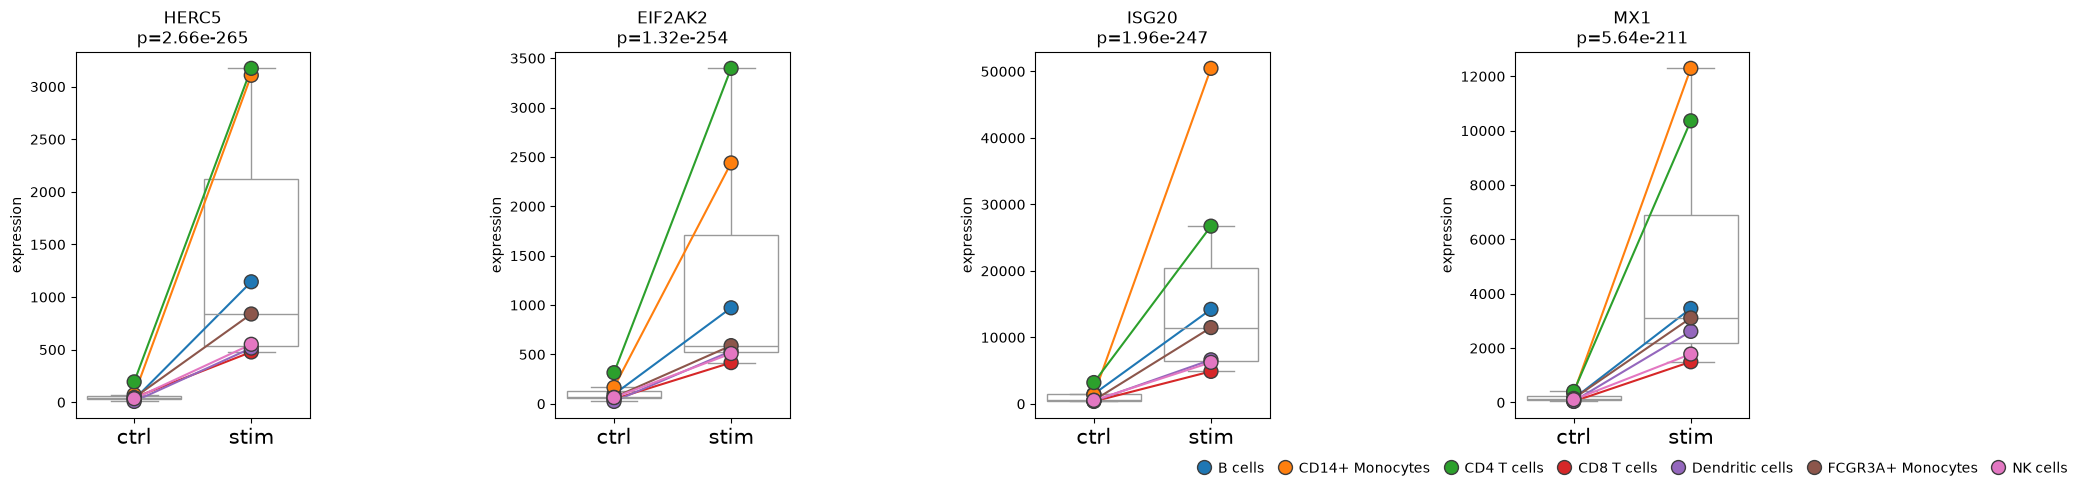

In [33]:
pds2.plot_paired(
    adata_pb,
    results_df=res_df,
    n_top_vars=4,
    groupby="label",
    pairedby="cell_type"
)

We can see that the top four differentially expressed genes show their strongest expression changes not only in CD14+ monocytes but also in CD4 T cells.

Now we could ask: Is the gene expression difference between `ctrl` and `stim` different between CD14+ Monocytes and CD4 T cells?
In other words, could the gene expression changes depend on the cell type?

To do so, we create a more complex [design matrix](#design-syntax) and then use contrasts to specify the conditions of interest.

In [34]:
pds2 = pt.tl.PyDESeq2(adata=adata_pb, design="~ cell_type * label")

In [35]:
pds2.fit()

Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...


... done in 0.69 seconds.

Fitting dispersion trend curve...
... done in 0.13 seconds.

Fitting MAP dispersions...


... done in 0.70 seconds.

Fitting LFCs...


... done in 0.84 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 3 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.



In [36]:
interaction_contrast = (
    pds2.cond(cell_type="CD14+ Monocytes", label="stim") -
    pds2.cond(cell_type="CD14+ Monocytes", label="ctrl")
) - (
    pds2.cond(cell_type="CD4 T cells", label="stim") -
    pds2.cond(cell_type="CD4 T cells", label="ctrl")
)

res_df = pds2.test_contrasts(interaction_contrast)

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0.  0.  0.  0.  0.  0.  0.  0.  1. -1.  0.  0.  0.  0.]
                baseMean  log2FoldChange      lfcSE      stat    pvalue  \
index                                                                     
AL627309.1      0.010607        1.740385  10.956334  0.158847  0.873789   
RP11-206L10.2   0.030188       -0.208432  10.939235 -0.019054  0.984798   
RP11-206L10.9   0.047391        0.917190  10.951037  0.083754  0.933252   
FAM87B          0.053617        0.882214  10.986500  0.080300  0.935999   
LINC00115       0.389827        0.455590   1.374591  0.331437  0.740315   
...                  ...             ...        ...       ...       ...   
C21orf58        0.121437        0.744934   4.380657  0.170051  0.864970   
PCNT            0.676612       -0.612979   1.088831 -0.562970  0.573455   
DIP2A           1.532521       -0.203085   0.684868 -0.296531  0.766825   
S100B           0.638731        0.746335   2.760212  0.270390 

... done in 0.99 seconds.



NaNs encountered, dropping rows with NaNs


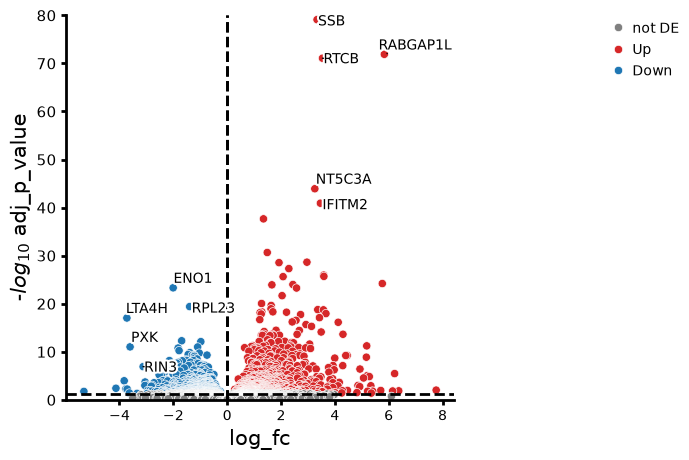

In [37]:
pds2.plot_volcano(res_df, log2fc_threshold=0)

As we can see, there are some genes that stand out in their differences in gene expression changes.
For example, the change in expression of _RABGAP1L_ is higher in CD14+ monocytes compared to CD4 T cells, while _ENO1_ shows a lower change.

We can also plot the fold changes of the top differentially expressed genes.
We only include genes that pass an adjusted p-value threshold, for example 0.01.

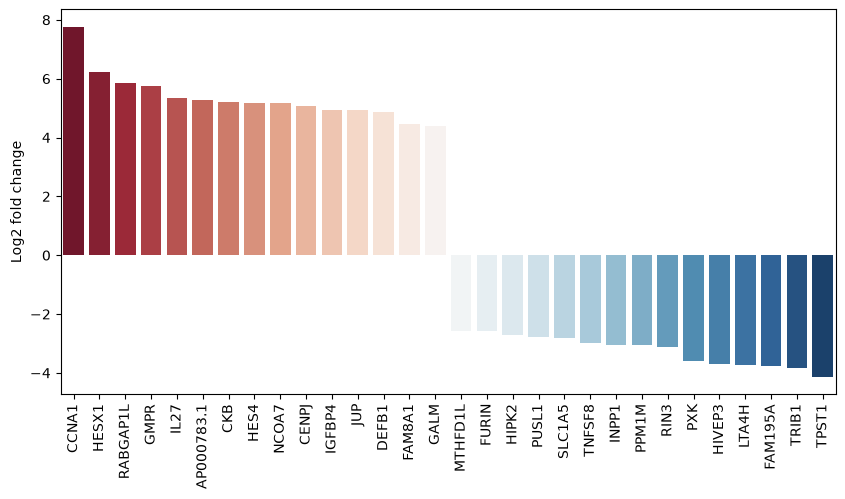

In [38]:
pds2.plot_fold_change(res_df, n_top_vars=15, padj_threshold=0.01)

Finally, we can also plot multiple comparisons.
In this case, we are comparing the gene expression of CD14+ monocytes to all other cell types.
Comparing cell types with each other should roughly reflect the marker genes used during annotation.
This therefore mainly shows what is possible and should ideally be replaced by your groups of interest (e.g., sex, responder vs. non-responder status or age groups).

In [39]:
res_df = pds2.compare_groups(adata_pb,
    column="cell_type",
    baseline="CD14+ Monocytes",
    groups_to_compare=list(set(adata_pb.obs["cell_type"].unique()) - {"CD14+ Monocytes"})
)

Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...


... done in 0.78 seconds.

Fitting dispersion trend curve...


... done in 0.22 seconds.

Fitting MAP dispersions...


...

Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.  0.  0.  1.  0.  0.]
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
index                                                                    
AL627309.1      0.010607        2.368673  5.495653  0.431009  0.666462   
RP11-206L10.2   0.030188        2.356867  5.388792  0.437365  0.661847   
RP11-206L10.9   0.047391        2.176679  4.449785  0.489165  0.624725   
FAM87B          0.053617        2.176522  5.486869  0.396678  0.691605   
LINC00115       0.389827        0.574409  0.876367  0.655443  0.512182   
...                  ...             ...       ...       ...       ...   
C21orf58        0.121437        2.037958  1.867642  1.091193  0.275188   
PCNT            0.676612        1.752893  0.702171  2.496389  0.012546   
DIP2A           1.532521       -0.969068  0.628551 -1.541749  0.123135   
S100B           0.638731        1.797298  1.482844  1.212061  0.225489   
PRMT2          24.013222   

... done in 0.69 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.  1.  0.  0.  0.  0.]
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
index                                                                    
AL627309.1      0.010607        0.161952  5.470482  0.029605  0.976382   
RP11-206L10.2   0.030188       -0.246900  5.379558 -0.045896  0.963393   
RP11-206L10.9   0.047391       -0.389012  4.435030 -0.087714  0.930104   
FAM87B          0.053617       -0.768141  5.492885 -0.139843  0.888784   
LINC00115       0.389827        0.908129  0.612080  1.483677  0.137895   
...                  ...             ...       ...       ...       ...   
C21orf58        0.121437        1.199311  1.736373  0.690699  0.489755   
PCNT            0.676612        1.931772  0.502355  3.845436  0.000120   
DIP2A           1.532521        0.735309  0.325070  2.262000  0.023697   
S100B           0.638731        4.501082  1.235556  3.642960  0.000270   
PRMT2          24.013222   

Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.  0.  1.  0.  0.  0.]
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
index                                                                    
AL627309.1      0.010607        3.396434  5.696649  0.596216  0.551031   
RP11-206L10.2   0.030188        3.074764  5.603562  0.548716  0.583200   
RP11-206L10.9   0.047391        3.140186  4.619123  0.679823  0.496617   
FAM87B          0.053617        3.074880  5.696030  0.539829  0.589315   
LINC00115       0.389827        1.314156  0.839140  1.566074  0.117331   
...                  ...             ...       ...       ...       ...   
C21orf58        0.121437        2.718598  1.954655  1.390833  0.164276   
PCNT            0.676612        2.018692  0.690447  2.923748  0.003458   
DIP2A           1.532521        1.157830  0.443741  2.609246  0.009074   
S100B           0.638731        3.976857  1.383712  2.874051  0.004052   
PRMT2          24.013222   

... done in 0.67 seconds.



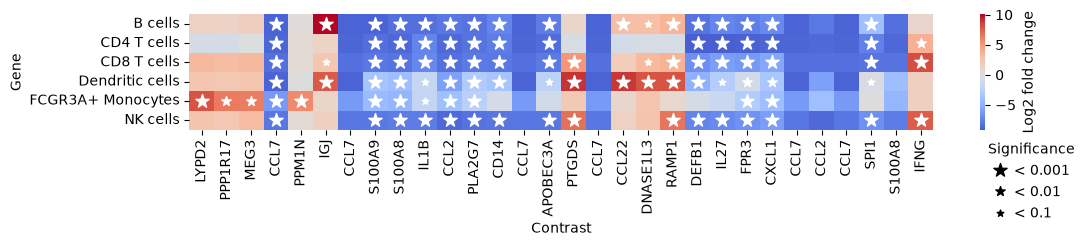

In [40]:
pds2.plot_multicomparison_fc(res_df, n_top_vars=5, figsize=(12, 1.5))

The plot shows genes that are differentially expressed in all other cell types compared to CD14+ monocytes.
For example, _CLL2_ and _CCL7_ are significantly less expressed in all other cell types compared to CD14+ monocytes.

## Questions

### Flipcards

In [41]:
%run ../../scripts/quiz.py

with quiz_tabs():
    flip_card("q1", "What is differential gene expression and in which cases are we interested in testing for it?", "DGE analysis identifies genes with significant expression differences between conditions, such as healthy versus diseased states, to elucidate underlying biological mechanisms.", back_font_size=13)
    flip_card("q2", "What is the 'pseudoreplication' problem and how can it be circumvented?", "In single-cell RNA sequencing, treating individual cells from the same subject as independent samples can inflate false discovery rates. This issue can be mitigated by aggregating data into 'pseudobulks' per subject or modeling subjects as random effects.", back_font_size=13)
    flip_card("q3", "What is the 'multiple testing' problem and how can it be eluded?", "Testing thousands of genes simultaneously increases the likelihood of false positives. To address this, corrections like the Benjamini-Hochberg procedure are applied to control the false discovery rate.", back_font_size=15)

### Multiple choice questions

In [42]:
%run ../../scripts/quiz.py

with quiz_tabs():
    multiple_choice_question(
        "q4",
        "What does a positive log2 fold change indicate in DESeq2 results?",
        [
            "The gene is expressed equally in both groups",
            "The gene is more expressed in the baseline group",
            "The gene is more expressed in the group of interest compared to baseline",
            "The gene was filtered out during preprocessing",
        ],
        "The gene is more expressed in the group of interest compared to baseline",
        {},
    )

    multiple_choice_question(
        "q6",
        "What is the purpose of PCA on pseudobulk samples before DGE testing?",
        [
            "To normalize gene expression counts",
            "To identify sources of variation that should be captured in the design matrix",
            "To cluster cells into subtypes",
            "To remove batch effects automatically",
        ],
        "To identify sources of variation that should be captured in the design matrix",
        {},
    )

    multiple_choice_question(
        "q8",
        "What does an interaction term like `cell_type:label` in a design matrix allow you to test?",
        [
            "Whether cell types differ in total read counts",
            "Whether the effect of treatment differs across cell types",
            "Whether replicates are correlated within patients",
            "Whether batch effects are present in the data",
        ],
        "Whether the effect of treatment differs across cell types",
        {},
    )

## Contributors

We gratefully acknowledge the contributions of:

### Authors

* Lukas Heumos
* Anastasia Litinetskaya
* Soroor Hediyeh-Zadeh
* Luis Heinzlmeier

### Reviewers